In [14]:

import torch
import torch.nn as nn
# from torch.autograd import Variable
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import utils as ul


cuda:0


### Solve the following optimizaiton problem with PDE
$$
\min -y(x)\\

\textbf{s.t.} \frac{dy}{dx} + ay + by^2 + e \leq 0\\

$$

In [15]:
### (2) Model
# net = ul.MetricNet2(input_dim=1,
#                     hidden_layers=[50, 30, 20, 10, 20, 30, 10],
#                     output_dim=1,
#                     dropout_prob=0.1).to(device)
net = ul.MetricNet().to(device)

In [16]:
# pde constraint
def con(x, net, a=0.10, b=0.02, epsilon=0.01):
    # Compute network output
    y = net(x)
    # Compute dy/dx using autograd
    dydx = torch.autograd.grad(y.sum(), x, create_graph=True)[0]
    # Ensure `torch.max()` operates on same-shaped tensors
    constraint = dydx + a * y + b * y * y + epsilon
    return torch.max(torch.zeros_like(constraint), constraint) ** 2

In [17]:
# pde boundary condition
y_0 = torch.tensor([[1.0]], device=device)
x_0 = torch.tensor([0.0], device=device)

In [18]:
### (3) Training / Fitting
# define pde parameters

a = 0.5
b = 0.1
epsilon = 0.01

# define optimizer
mse_cost_function = torch.nn.MSELoss() # Mean squared error
optimizer = torch.optim.Adam(net.parameters(), betas=(0.9, 0.999))

from tqdm import tqdm
#from torch.utils.tensorboard import SummaryWriter
# tensorboard
#writer = SummaryWriter()

# change the learing rate according to number of steps passed
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.7)

iterations = 20000
patience = 3000  # Number of epochs to wait before stopping if no improvement
best_loss = float('inf')
epochs_without_improvement = 0

net.train()
train_loss = []

# training domain
b0 = -3.0
b1 = 20.0
# number of sampling points in x traing domain
N_sample = 500

for epoch in tqdm(range(iterations)):
    optimizer.zero_grad() # to make the gradients zero

    # Loss based on ODE
    x_collocation = np.random.uniform(low=b0, high=b1, size=(N_sample,1)) # collocation points
    all_zeros = np.zeros((N_sample, 1))
    
    pt_x_collocation = torch.from_numpy(x_collocation).float().to(device)
    pt_x_collocation.requires_grad=True

    # cost value
    y_out = -net(pt_x_collocation)
    # constraints
    con_out = con(pt_x_collocation, net, a=a, b=b, epsilon=epsilon)
    # fixed point constraint
    ec0 = (net(x_0) - y_0) ** 2
    

    mse_f = y_out.sum() / N_sample
    mes_con = con_out.sum() / N_sample

    # Combining the loss functions
    loss = mse_f + 10.0 * mes_con + 10.0 * ec0
    #loss = mse_f + 100.0 * mes_con

    loss.backward() # This is for computing gradients using backward propagation
    optimizer.step() # This is equivalent to : theta_new = theta_old - alpha * derivative of J w.r.t theta

    # with torch.autograd.no_grad():
    train_loss.append(loss.item())
    
    # Learning rate update
    scheduler.step()
    
    # Log GPU usage
    # writer.add_scalar("GPU Memory Allocated", torch.cuda.memory_allocated(), epoch)
    # writer.add_scalar("GPU Memory Reserved", torch.cuda.memory_reserved(), epoch)
    
    # -------------------
    # Early Stopping Check
    # -------------------
    if loss.item() < best_loss:
        best_loss = loss.item()
        epochs_without_improvement = 0  # Reset counter
    else:
        epochs_without_improvement += 1
    
    # Stop training if no improvement for 'patience' epochs
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch}. Best loss: {best_loss:.6f}")
        break  # Exit the training loop

# effective iterations
eff_itrs = epoch
# writer.close()

 51%|█████     | 10161/20000 [00:43<00:41, 235.89it/s]


Early stopping triggered at epoch 10161. Best loss: 0.086858


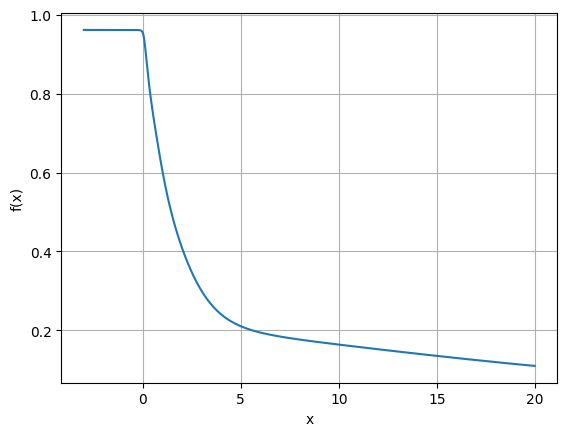

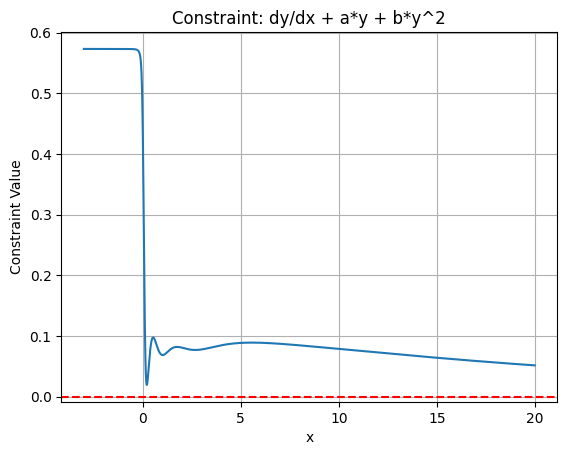

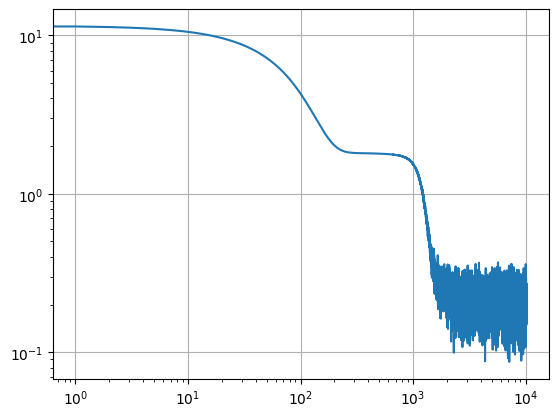

In [19]:
# evaluation
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import numpy as np


net.eval()

# plot the figure of f(x)
x = np.arange(b0, b1, 0.01).reshape(-1, 1)

pt_x = torch.from_numpy(x).float().to(device)
pt_x.requires_grad=True
# evaluation of the net
pt_u = net(pt_x)
# compute the graident
dy = torch.autograd.grad(pt_u, pt_x, grad_outputs=torch.ones_like(pt_u), create_graph=True)[0]
# calculate constraint
dydx = dy + a * pt_u + b * pt_u * pt_u

u = pt_u.data.detach().cpu().numpy()
c = dydx.data.detach().cpu().numpy()

# plot the figure of f(x)
fig = plt.figure()
plt.plot(x, u)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
# plot the figure of dydx + a * y + b * y * y
fig = plt.figure()
plt.plot(x, c)
plt.axhline(0, color='red', linestyle='--', label="Zero Line")  # Dashed red line at zero
plt.title("Constraint: dy/dx + a*y + b*y^2")
plt.xlabel("x")
plt.ylabel("Constraint Value")
plt.grid(True)
# plot the figure of the training loss
fig = plt.figure()
plt.plot(range(0, eff_itrs + 1), train_loss)
plt.xscale('log')
plt.yscale('log')
plt.grid(True)